# Solución | Tarea 2

In [1]:
import csv
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import accuracy_score, recall_score, precision_score
import seaborn as sns


## Regresión

Basado en las condiciones del estudiantes vamos a predecir el puntaje que tendrá en las pruebas del saber en lectura critica “PUNT_GLOBAL”.

### 1. Realizar la exploración de los datos correlación, scatter plots, boxplots e histogramas

#### 1.1 ¿Qué variables son importantes para predecir el valor?

Voy a separar algunas columnas irrelevantes

In [2]:
est_train_raw = pd.read_csv("data/training_pruebas.csv", low_memory=False)

In [3]:
irrelevant_cols = [
    "ESTU_TIPODOCUMENTO", "ESTU_NACIONALIDAD","PERIODO","ESTU_CONSECUTIVO","ESTU_ESTUDIANTE","ESTU_PAIS_RESIDE",
    "ESTU_DEPTO_RESIDE","ESTU_MCPIO_RESIDE","ESTU_ESTADOCIVIL","ESTU_TIPODOCUMENTOSB11","FAMI_EDUCACIONPADRE","FAMI_EDUCACIONMADRE",
    "FAMI_TRABAJOLABORPADRE","FAMI_TRABAJOLABORMADRE","FAMI_CUANTOSCOMPARTEBAÑO",
    "ESTU_PRESENTACIONCASA","ESTU_PRESENTACIONSABADO","INST_NOMBRE_INSTITUCION","ESTU_PRGM_ACADEMICO","GRUPOREFERENCIA",
    "ESTU_PRGM_MUNICIPIO","ESTU_PRGM_DEPARTAMENTO","ESTU_NUCLEO_PREGRADO","ESTU_NUCLEO_PREGRADO_1",
    "ESTU_INST_MUNICIPIO","ESTU_INST_DEPARTAMENTO","ESTU_MCPIO_PRESENTACION",
    "ESTU_DEPTO_PRESENTACION","ESTU_ESTADOINVESTIGACION", "ESTU_COD_RESIDE_DEPTO", "ESTU_COD_RESIDE_MCPIO",
    "ESTU_SNIES_PRGMACADEMICO","ESTU_PRGM_CODMUNICIPIO","ESTU_INST_CODMUNICIPIO","ESTU_COD_MCPIO_PRESENTACION","ESTU_COD_DEPTO_PRESENTACION"
]

est_train = est_train_raw.drop(columns = irrelevant_cols)

#### 1.2 Existen nulos?, ¿cómo se deben imputar?

In [4]:
continuous_cols = ["ESTU_INSE_INDIVIDUAL","ESTU_NSE_INDIVIDUAL", "ESTU_NSE_IES"]
categorical_cols = [col for col in est_train.columns if (col not in continuous_cols) and (col != "PUNT_GLOBAL")]

def fix_nulls(data):

    new_data = data.copy()
    mean = new_data[continuous_cols].mean()
    mode = new_data[categorical_cols].mode()

    # Llenar nulos con la media para variables numéricas
    for col in new_data[continuous_cols]:
        for i, val in enumerate(new_data[col]):
            if math.isnan(val):
                new_data.loc[i, col] = mean[col]

    # Llenar nulos con la moda para variables categóricas
    new_data[categorical_cols] = new_data[categorical_cols].apply(lambda x: x.fillna(x.value_counts().index[0]))

    return new_data

est_train = fix_nulls(est_train)

for i, val in enumerate(est_train["PUNT_GLOBAL"]):
    if math.isnan(val):
        est_train.loc[i, col] = est_train["PUNT_GLOBAL"].mean()

#### 1.3 Crear dummy variables para incluirlas en la correlación

Primero voy a sanitizar algunas variables catégoricas, para no crear demasiados dummies

In [5]:
def transform_data(data):

    # Obtener edad actual de cada persona
    data["ESTU_FECHANACIMIENTO"] = pd.to_datetime(data["ESTU_FECHANACIMIENTO"], format="mixed", dayfirst=True, errors='coerce')
    today = pd.to_datetime('today', format="%d/%m/%Y")
    data["ESTU_FECHANACIMIENTO"] = data["ESTU_FECHANACIMIENTO"].apply(lambda x: today.year - x.year - ((today.month, today.day) < (x.month, x.day)))
    age_mean = data["ESTU_FECHANACIMIENTO"].mean()

    for i, val in enumerate(data["ESTU_FECHANACIMIENTO"]):
        if str(val) == 'nan':
            data.loc[i, "ESTU_FECHANACIMIENTO"] = age_mean

    # Trasnformar valores dicotómicos

    # Genero (M: 0, F: 1)
    data["ESTU_GENERO"] = data["ESTU_GENERO"].apply(lambda x: 1 if x == 'F' else 0)

    # Estudia en el exterior (NO: 0, SI: 1)
    data["ESTU_EXTERIOR"] = data["ESTU_EXTERIOR"].apply(lambda x: 1 if x == 'SI' else 0)

    # Área de residencia (Area Rural: 0, Cabecera Municipal: 1)
    data["ESTU_AREARESIDE"] = data["ESTU_AREARESIDE"].apply(lambda x: 1 if x == 'Cabecera Municipal' else 0)

    # Pago con beca
    data["ESTU_PAGOMATRICULABECA"] = data["ESTU_PAGOMATRICULABECA"].apply(lambda x: 1 if x == 'Si' else 0)
    # Pago con crédito
    data["ESTU_PAGOMATRICULACREDITO"] = data["ESTU_PAGOMATRICULACREDITO"].apply(lambda x: 1 if x == 'Si' else 0)
    # Pago con padres
    data["ESTU_PAGOMATRICULAPADRES"] = data["ESTU_PAGOMATRICULAPADRES"].apply(lambda x: 1 if x == 'Si' else 0)
    # Pago propio
    data["ESTU_PAGOMATRICULAPROPIO"] = data["ESTU_PAGOMATRICULAPROPIO"].apply(lambda x: 1 if x == 'Si' else 0)

    # Hizo simulacro
    data["ESTU_SIMULACROTIPOICFES"] = data["ESTU_SIMULACROTIPOICFES"].apply(lambda x: 1 if x == 'Si' else 0)
    # Hizo actividades de refuerzo en áreas
    data["ESTU_ACTIVIDADREFUERZOAREAS"] = data["ESTU_ACTIVIDADREFUERZOAREAS"].apply(lambda x: 1 if x == 'Si' else 0)
    # Hizo actividades de refuerzo genéricas
    data["ESTU_ACTIVIDADREFUERZOGENERIC"] = data["ESTU_ACTIVIDADREFUERZOGENERIC"].apply(lambda x: 1 if x == 'Si' else 0)

    # Tiene internet
    data["FAMI_TIENEINTERNET"] = data["FAMI_TIENEINTERNET"].apply(lambda x: 1 if x == 'Si' else 0)
    # Tiene computador
    data["FAMI_TIENECOMPUTADOR"] = data["FAMI_TIENECOMPUTADOR"].apply(lambda x: 1 if x == 'Si' else 0)
    # Tiene lavadora
    data["FAMI_TIENELAVADORA"] = data["FAMI_TIENELAVADORA"].apply(lambda x: 1 if x == 'Si' else 0)
    # Tiene microondas
    data["FAMI_TIENEHORNOMICROOGAS"] = data["FAMI_TIENEHORNOMICROOGAS"].apply(lambda x: 1 if x == 'Si' else 0)
    # Tiene TV
    data["FAMI_TIENESERVICIOTV"] = data["FAMI_TIENESERVICIOTV"].apply(lambda x: 1 if x == 'Si' else 0)
    # Tiene automovil
    data["FAMI_TIENEAUTOMOVIL"] = data["FAMI_TIENEAUTOMOVIL"].apply(lambda x: 1 if x == 'Si' else 0)
    # Tiene motocicleta
    data["FAMI_TIENEMOTOCICLETA"] = data["FAMI_TIENEMOTOCICLETA"].apply(lambda x: 1 if x == 'Si' else 0)
    # Tiene consola de videojuegos
    data["FAMI_TIENECONSOLAVIDEOJUEGOS"] = data["FAMI_TIENECONSOLAVIDEOJUEGOS"].apply(lambda x: 1 if x == 'Si' else 0)

    # Método del programa (PRESENCIAL: 0 DISTANCIA VITUAL: 1)
    data["ESTU_METODO_PRGM"] = data["ESTU_METODO_PRGM"].apply(lambda x: 1 if x == 'DISTANCIA VITUAL' else 0)

    # Privado de libertad
    data["ESTU_PRIVADO_LIBERTAD"] = data["ESTU_PRIVADO_LIBERTAD"].apply(lambda x: 1 if x == 'S' else 0)

transform_data(est_train)
print("Nulos: ", np.nonzero(pd.isnull(est_train)))
est_train

Nulos:  (array([], dtype=int64), array([], dtype=int64))


,ESTU_GENERO,ESTU_FECHANACIMIENTO,ESTU_EXTERIOR,ESTU_AREARESIDE,ESTU_TITULOOBTENIDOBACHILLER,ESTU_VALORMATRICULAUNIVERSIDAD,ESTU_PAGOMATRICULABECA,ESTU_PAGOMATRICULACREDITO,ESTU_PAGOMATRICULAPADRES,ESTU_PAGOMATRICULAPROPIO,...,INST_COD_INSTITUCION,ESTU_NIVEL_PRGM_ACADEMICO,ESTU_METODO_PRGM,INST_CARACTER_ACADEMICO,INST_ORIGEN,ESTU_PRIVADO_LIBERTAD,PUNT_GLOBAL,ESTU_INSE_INDIVIDUAL,ESTU_NSE_INDIVIDUAL,ESTU_NSE_IES
0,0,24.0,0,1,Bachiller académico,Entre 500 mil y menos de 1 millón,1,0,0,0,...,1202,UNIVERSITARIO,0,UNIVERSIDAD,OFICIAL DEPARTAMENTAL,0,188,55.570156,3.000000,2
1,0,23.0,0,1,Bachiller académico,Entre 1 millón y menos de 2.5 millones,1,0,0,0,...,2102,UNIVERSITARIO,0,UNIVERSIDAD,OFICIAL NACIONAL,0,140,38.105883,1.000000,2
2,1,28.0,0,1,Bachiller académico,Entre 1 millón y menos de 2.5 millones,1,0,0,0,...,2102,UNIVERSITARIO,0,UNIVERSIDAD,OFICIAL NACIONAL,0,140,65.658631,4.000000,2
3,1,29.0,0,1,Bachiller académico,No pagó matrícula,1,0,1,0,...,1218,UNIVERSITARIO,0,UNIVERSIDAD,OFICIAL DEPARTAMENTAL,0,111,49.260729,2.000000,2
4,1,46.0,0,1,Bachiller académico,Entre 2.5 millones y menos de 4 millones,0,0,0,1,...,2812,UNIVERSITARIO,1,UNIVERSIDAD,NO OFICIAL - CORPORACIÓN,0,135,55.138843,2.000000,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111425,1,24.0,0,1,Bachiller técnico,No pagó matrícula,1,0,1,0,...,1107,UNIVERSITARIO,0,UNIVERSIDAD,OFICIAL NACIONAL,0,137,55.028124,2.678834,2
111426,1,24.0,0,1,Bachiller académico,Entre 4 millones y menos de 5.5 millones,1,0,1,0,...,1805,UNIVERSITARIO,0,UNIVERSIDAD,NO OFICIAL - CORPORACIÓN,0,161,63.619372,4.000000,3
111427,0,60.0,0,1,Bachiller académico,Entre 2.5 millones y menos de 4 millones,0,0,0,1,...,4702,UNIVERSITARIO,0,INSTITUCIÓN TECNOLÓGICA,NO OFICIAL - FUNDACIÓN,0,124,48.648902,2.000000,2
111428,1,23.0,0,1,Bachiller académico,Entre 4 millones y menos de 5.5 millones,0,1,0,0,...,1824,UNIVERSITARIO,0,UNIVERSIDAD,NO OFICIAL - CORPORACIÓN,0,142,52.877602,2.000000,4


In [6]:
def normalize(data):
    for i, col in enumerate(data.columns):
        data[col] = 0 if data[col].std() == 0 else (data[col] - data[col].mean()) / data[col].std()

# Crear dummies
est_train_dumm = pd.get_dummies(est_train)
normalize(est_train_dumm)
est_train_dumm

,ESTU_GENERO,ESTU_FECHANACIMIENTO,ESTU_EXTERIOR,ESTU_AREARESIDE,ESTU_PAGOMATRICULABECA,ESTU_PAGOMATRICULACREDITO,ESTU_PAGOMATRICULAPADRES,ESTU_PAGOMATRICULAPROPIO,ESTU_SIMULACROTIPOICFES,ESTU_ACTIVIDADREFUERZOAREAS,...,INST_CARACTER_ACADEMICO_INSTITUCIÓN TECNOLÓGICA,INST_CARACTER_ACADEMICO_INSTITUCIÓN UNIVERSITARIA,INST_CARACTER_ACADEMICO_TÉCNICA PROFESIONAL,INST_CARACTER_ACADEMICO_UNIVERSIDAD,INST_ORIGEN_NO OFICIAL - CORPORACIÓN,INST_ORIGEN_NO OFICIAL - FUNDACIÓN,INST_ORIGEN_OFICIAL DEPARTAMENTAL,INST_ORIGEN_OFICIAL MUNICIPAL,INST_ORIGEN_OFICIAL NACIONAL,INST_ORIGEN_REGIMEN ESPECIAL
0,-1.141938,-0.708674,-0.123835,0.37177,1.534565,-0.617858,-0.834938,-0.942998,0.075645,0.098651,...,-0.234921,-0.767768,-0.180317,0.913065,-0.666591,-0.68761,2.347308,-0.172308,-0.481342,-0.027792
1,-1.141938,-0.852228,-0.123835,0.37177,1.534565,-0.617858,-0.834938,-0.942998,0.075645,0.098651,...,-0.234921,-0.767768,-0.180317,0.913065,-0.666591,-0.68761,-0.426016,-0.172308,2.077504,-0.027792
2,0.875696,-0.134462,-0.123835,0.37177,1.534565,-0.617858,-0.834938,-0.942998,0.075645,0.098651,...,-0.234921,-0.767768,-0.180317,0.913065,-0.666591,-0.68761,-0.426016,-0.172308,2.077504,-0.027792
3,0.875696,0.009092,-0.123835,0.37177,1.534565,-0.617858,1.197683,-0.942998,0.075645,0.098651,...,-0.234921,-0.767768,-0.180317,0.913065,-0.666591,-0.68761,2.347308,-0.172308,-0.481342,-0.027792
4,0.875696,2.449496,-0.123835,0.37177,-0.651645,-0.617858,-0.834938,1.060439,0.075645,0.098651,...,-0.234921,-0.767768,-0.180317,0.913065,1.500156,-0.68761,-0.426016,-0.172308,-0.481342,-0.027792
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111425,0.875696,-0.708674,-0.123835,0.37177,1.534565,-0.617858,1.197683,-0.942998,0.075645,0.098651,...,-0.234921,-0.767768,-0.180317,0.913065,-0.666591,-0.68761,-0.426016,-0.172308,2.077504,-0.027792
111426,0.875696,-0.708674,-0.123835,0.37177,1.534565,-0.617858,1.197683,-0.942998,0.075645,0.098651,...,-0.234921,-0.767768,-0.180317,0.913065,1.500156,-0.68761,-0.426016,-0.172308,-0.481342,-0.027792
111427,-1.141938,4.459241,-0.123835,0.37177,-0.651645,-0.617858,-0.834938,1.060439,0.075645,0.098651,...,4.256713,-0.767768,-0.180317,-1.095202,-0.666591,1.45430,-0.426016,-0.172308,-0.481342,-0.027792
111428,0.875696,-0.852228,-0.123835,0.37177,-0.651645,1.618480,-0.834938,-0.942998,0.075645,0.098651,...,-0.234921,-0.767768,-0.180317,0.913065,1.500156,-0.68761,-0.426016,-0.172308,-0.481342,-0.027792


#### 1.4 Crear una correlación, que variables tienen un efecto positivo en el puntaje y cuales un efecto negativo.

In [7]:
est_train_dumm.corrwith(est_train_dumm["PUNT_GLOBAL"]).sort_values(ascending=False).iloc[1:]

/home/smorenova/Projects/EST_III_UCO/tarea2/src/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/smorenova/Projects/EST_III_UCO/tarea2/src/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


INST_CARACTER_ACADEMICO_UNIVERSIDAD                                  0.292784
ESTU_NSE_IES                                                         0.262818
ESTU_VALORMATRICULAUNIVERSIDAD_Más de 7 millones                     0.244534
ESTU_INSE_INDIVIDUAL                                                 0.238292
ESTU_NSE_INDIVIDUAL                                                  0.215721
                                                                       ...   
ESTU_VLRULTIMOSEMESCURSADO_Entre un millon y 3 millones de pesose   -0.185439
INST_COD_INSTITUCION                                                -0.205356
INST_CARACTER_ACADEMICO_INSTITUCIÓN UNIVERSITARIA                   -0.223687
ESTU_FECHANACIMIENTO                                                -0.252675
ESTU_NIVEL_PRGM_ACADEMICO_UNIVERSITARIO                                   NaN
Length: 118, dtype: float64

Al realizar la correlación de cada variable contra PUNT_GLOBAL, se pueden observar las variables que tienen un efecto positivo en la parte superior; y las que tienen un efecto negativo en la parte inferior. El nivel socioeconómico es la variable que más influencia en el puntaje global.

<Figure size 300x100 with 0 Axes>

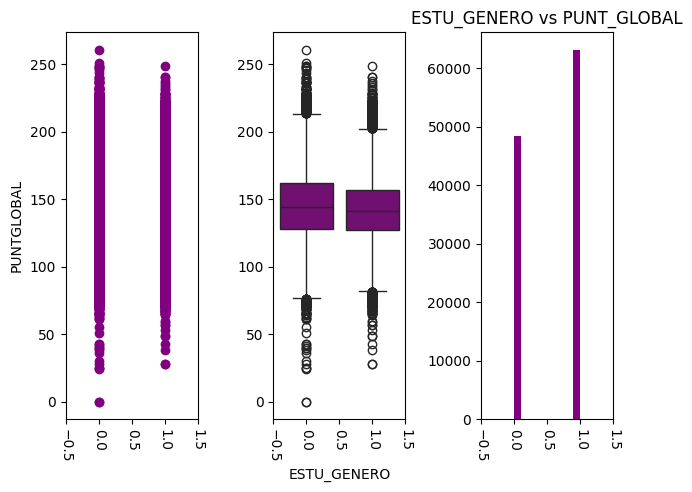

<Figure size 300x100 with 0 Axes>

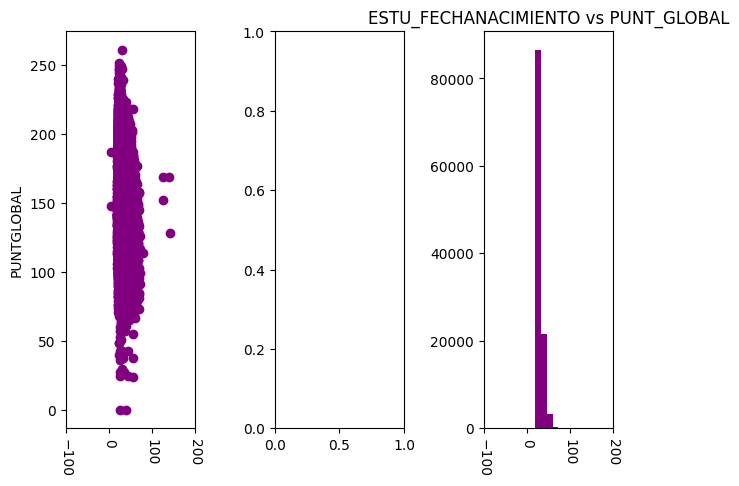

<Figure size 300x100 with 0 Axes>

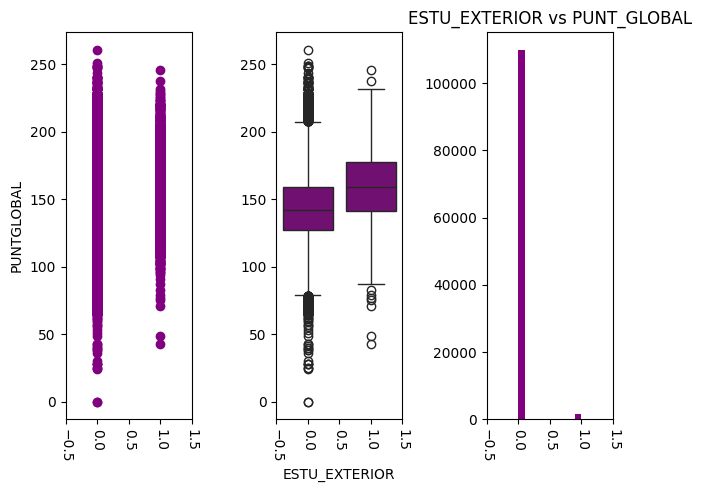

<Figure size 300x100 with 0 Axes>

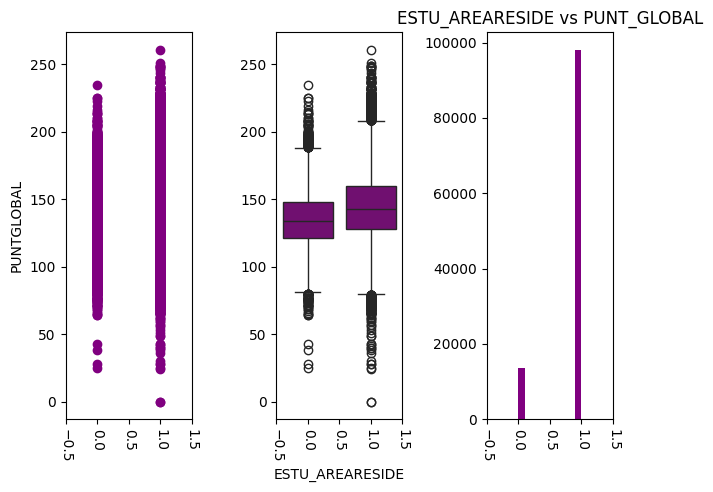

<Figure size 300x100 with 0 Axes>

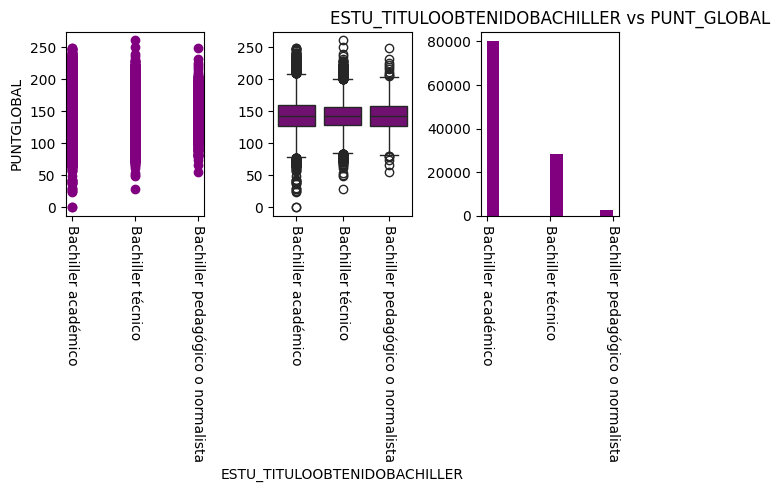

<Figure size 300x100 with 0 Axes>

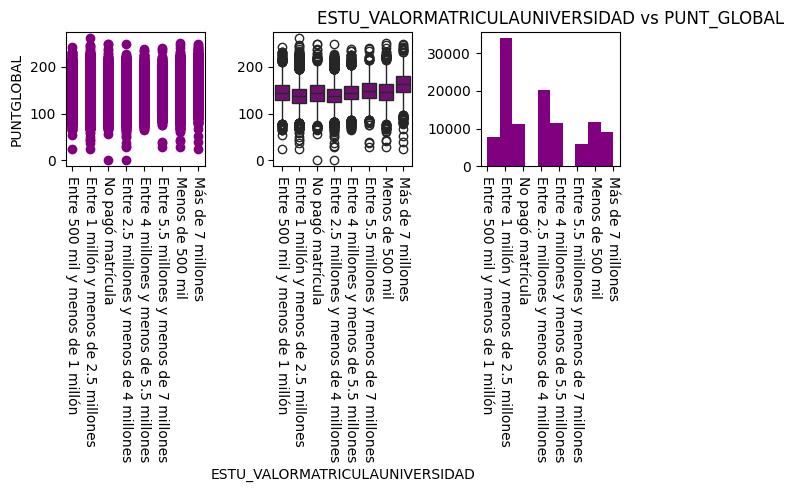

<Figure size 300x100 with 0 Axes>

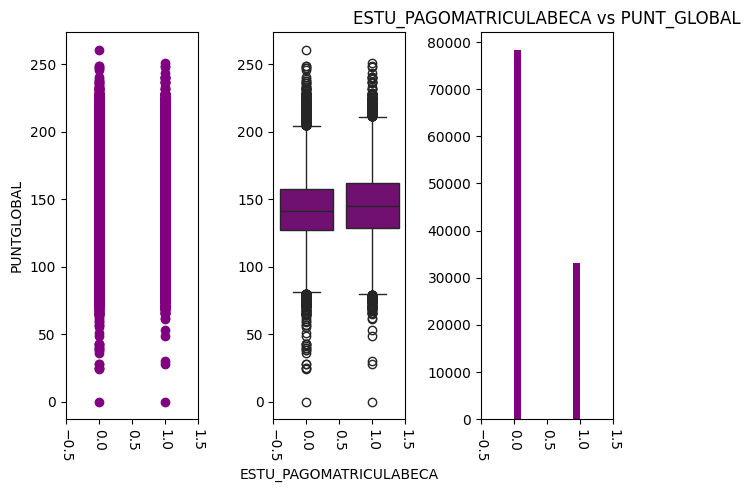

<Figure size 300x100 with 0 Axes>

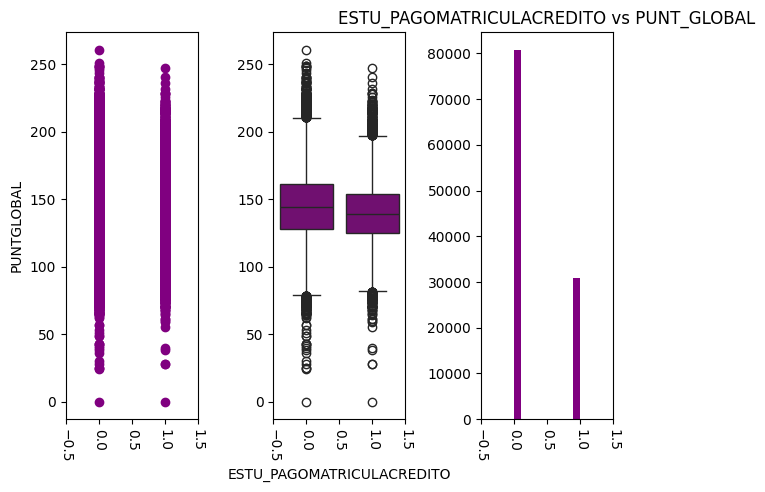

<Figure size 300x100 with 0 Axes>

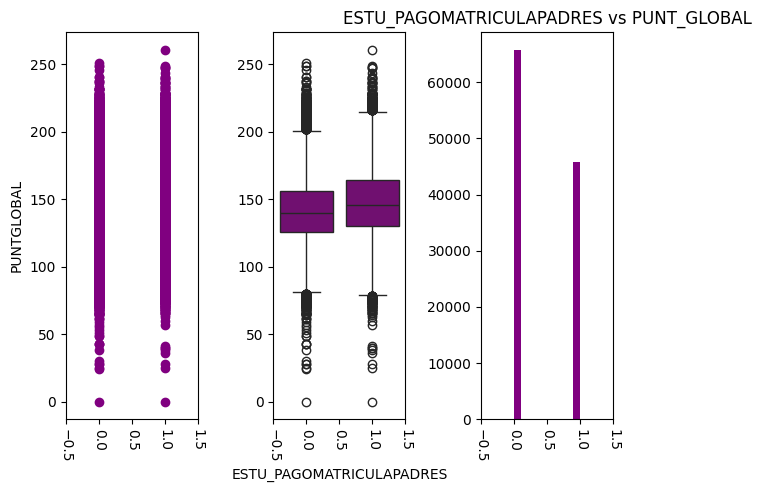

<Figure size 300x100 with 0 Axes>

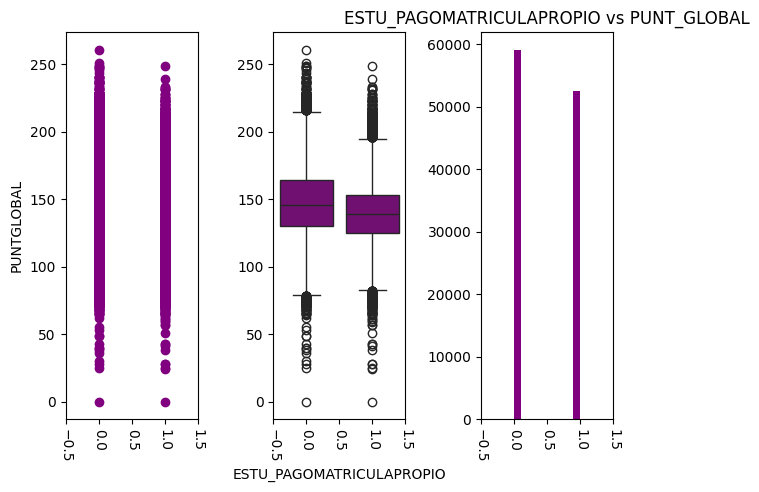

<Figure size 300x100 with 0 Axes>

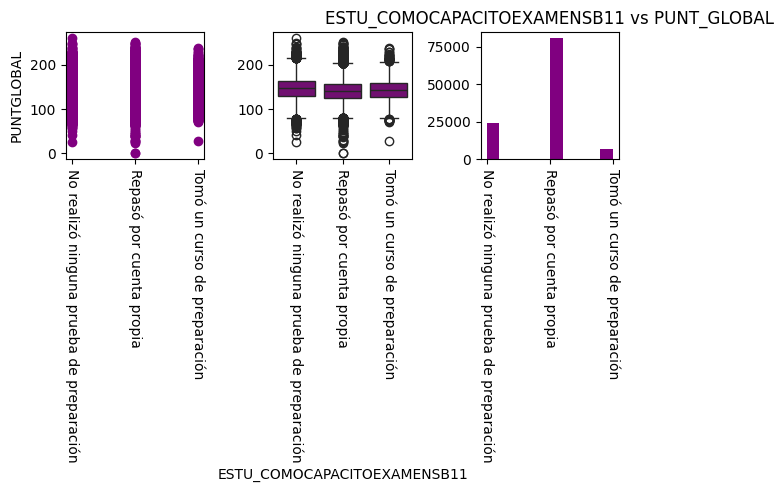

<Figure size 300x100 with 0 Axes>

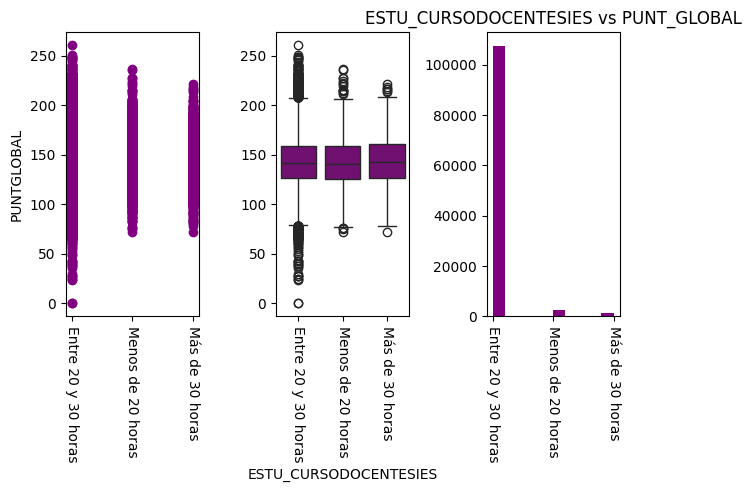

<Figure size 300x100 with 0 Axes>

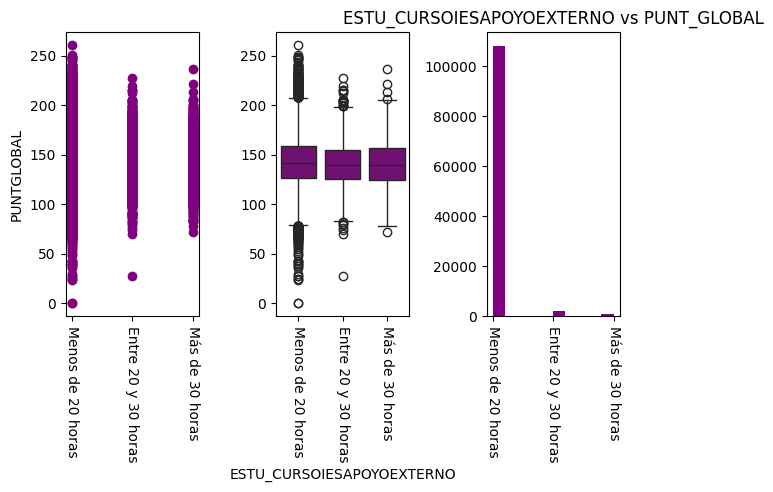

<Figure size 300x100 with 0 Axes>

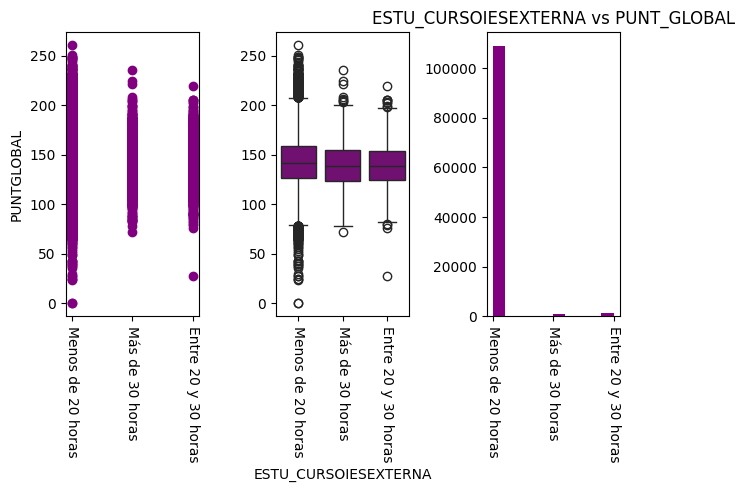

<Figure size 300x100 with 0 Axes>

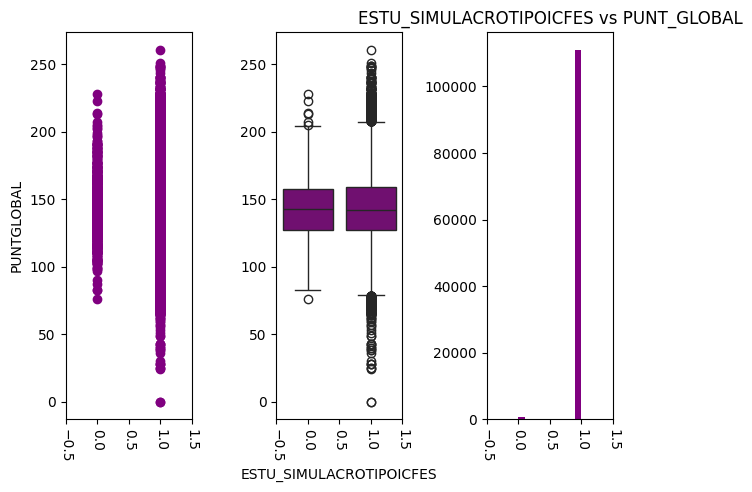

<Figure size 300x100 with 0 Axes>

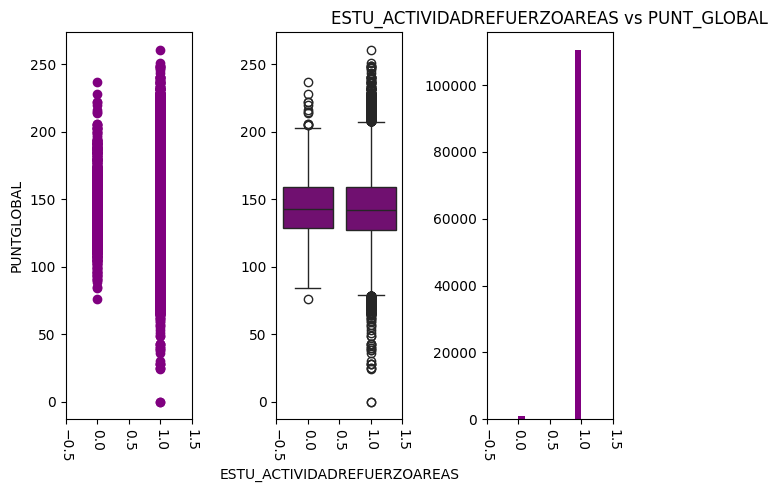

<Figure size 300x100 with 0 Axes>

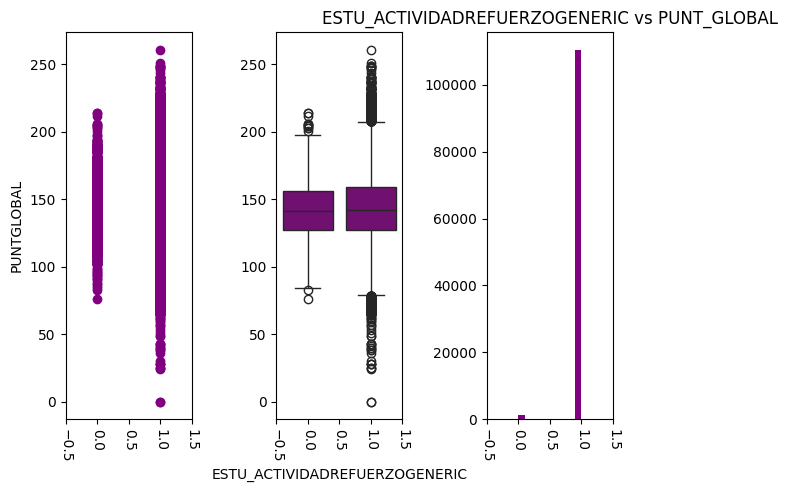

<Figure size 300x100 with 0 Axes>

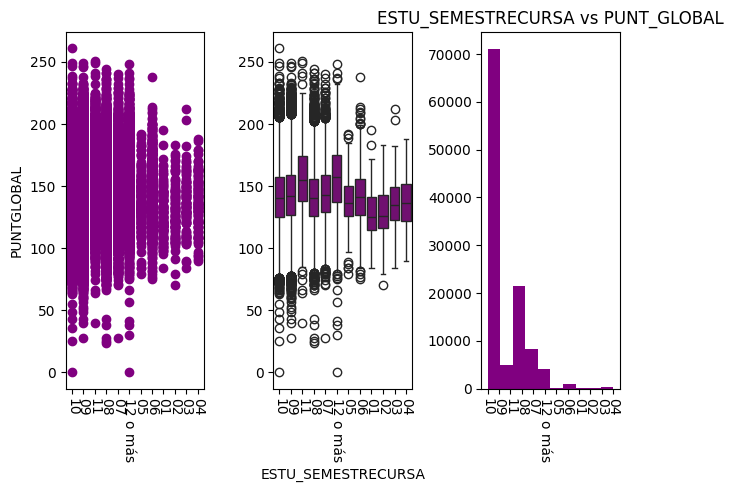

<Figure size 300x100 with 0 Axes>

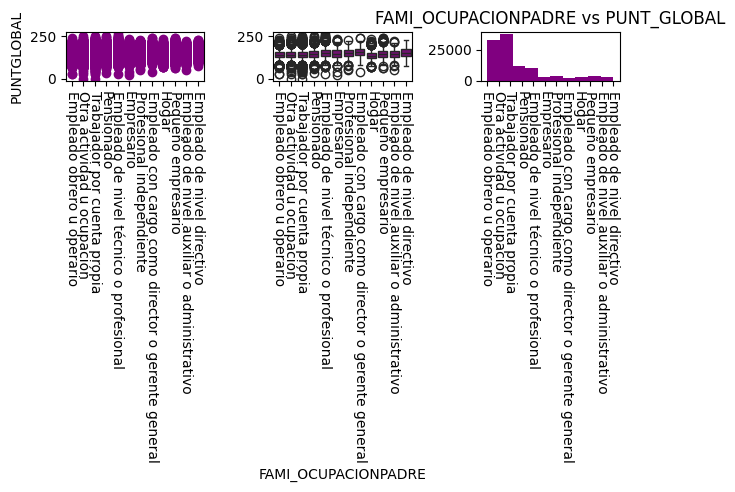

<Figure size 300x100 with 0 Axes>

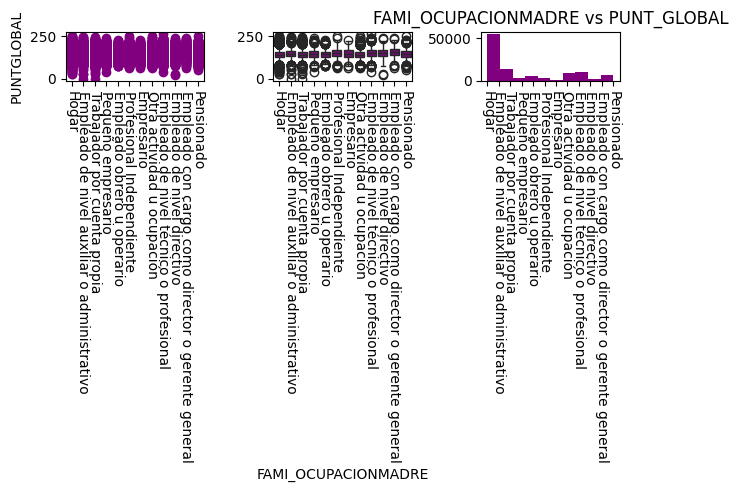

<Figure size 300x100 with 0 Axes>

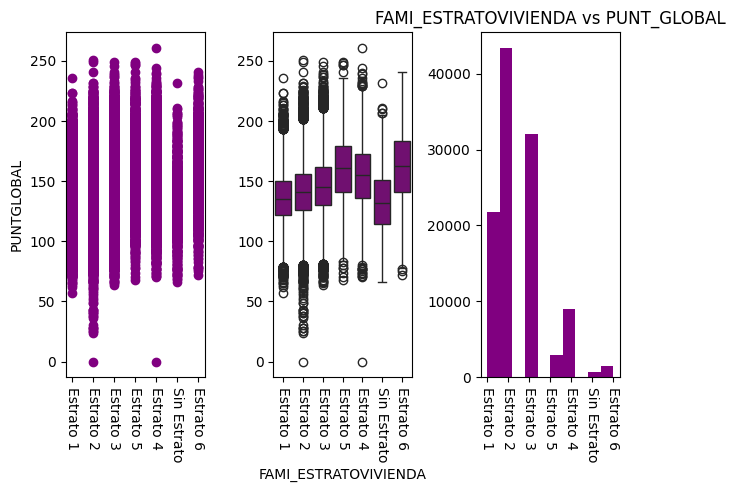

<Figure size 300x100 with 0 Axes>

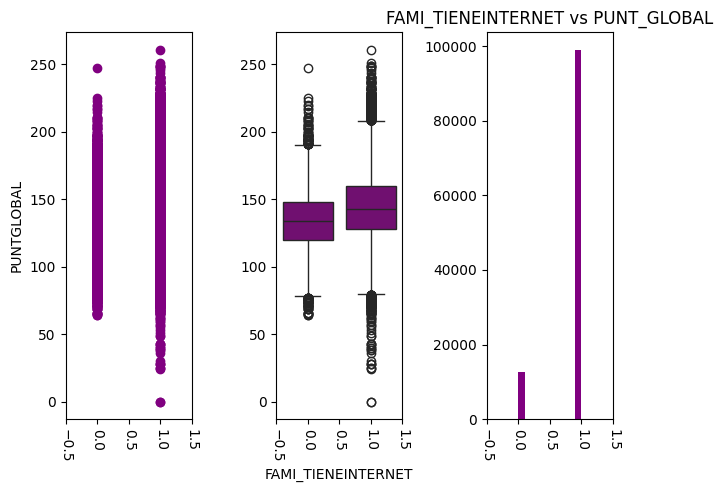

<Figure size 300x100 with 0 Axes>

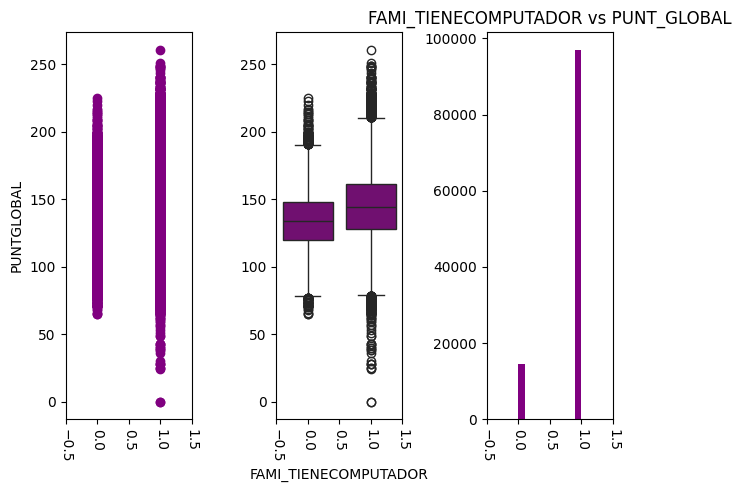

<Figure size 300x100 with 0 Axes>

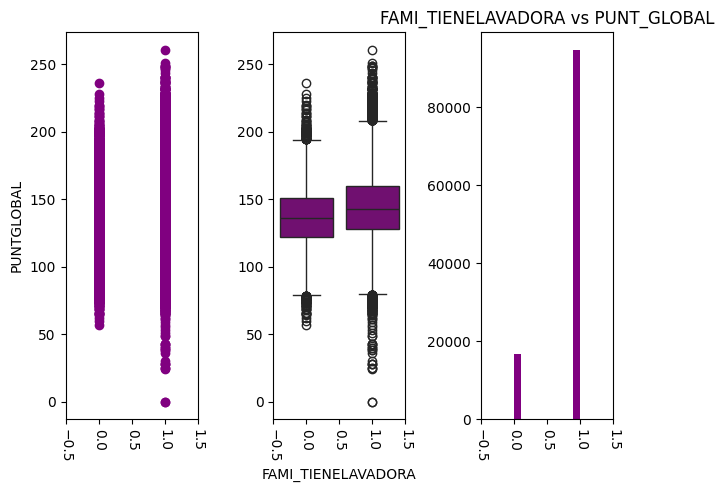

<Figure size 300x100 with 0 Axes>

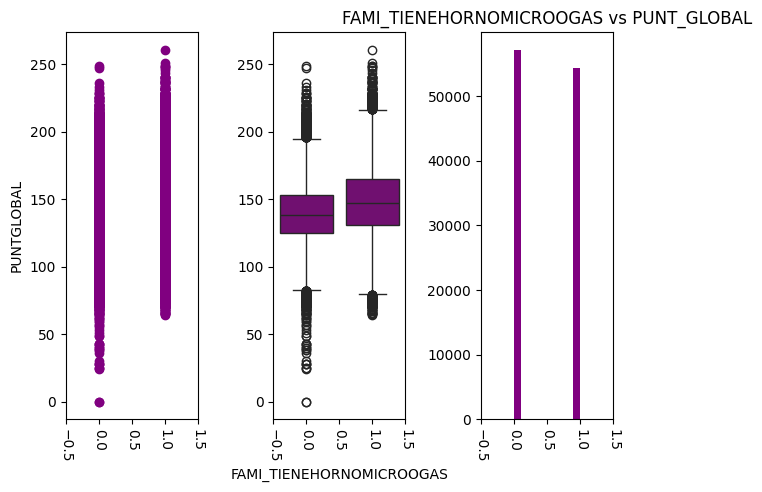

<Figure size 300x100 with 0 Axes>

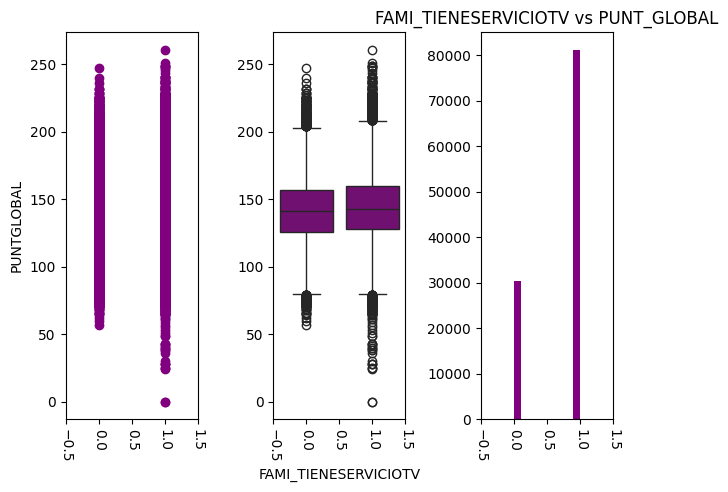

<Figure size 300x100 with 0 Axes>

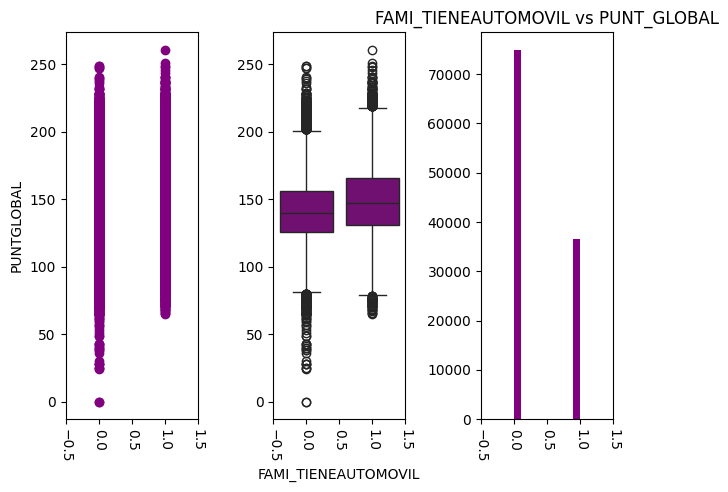

<Figure size 300x100 with 0 Axes>

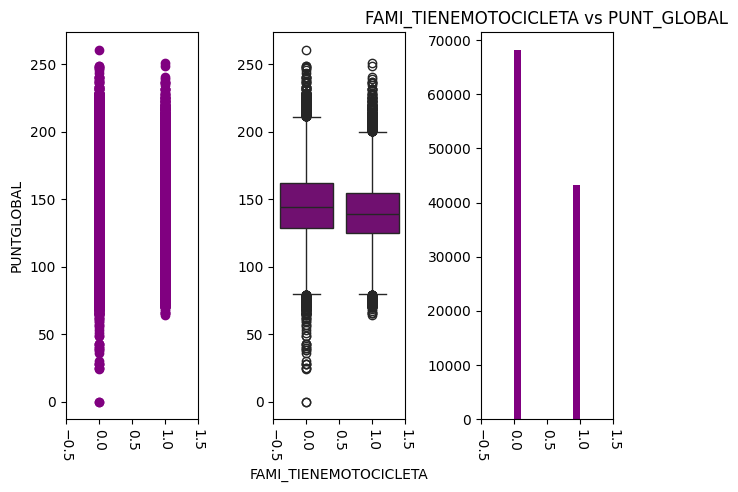

<Figure size 300x100 with 0 Axes>

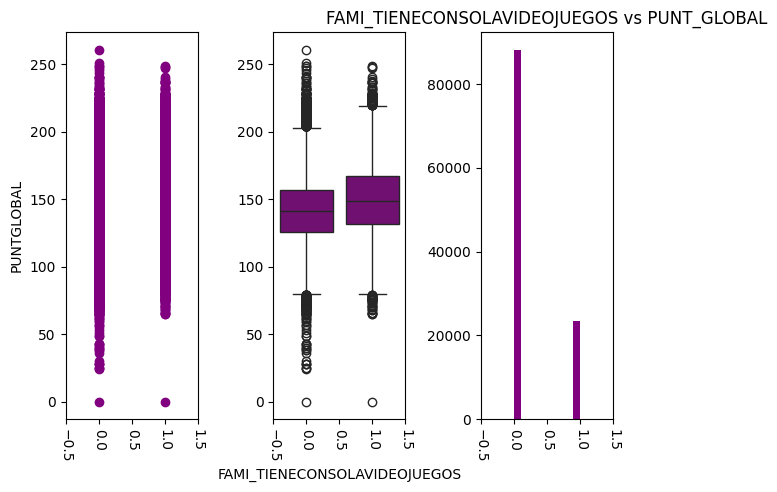

<Figure size 300x100 with 0 Axes>

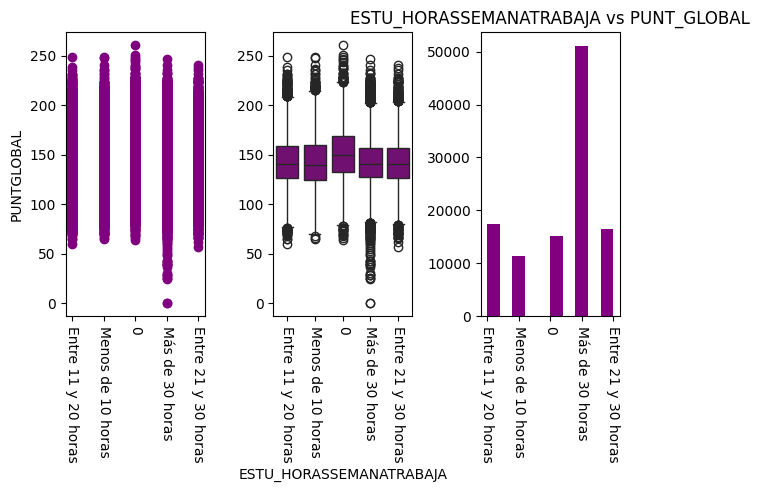

<Figure size 300x100 with 0 Axes>

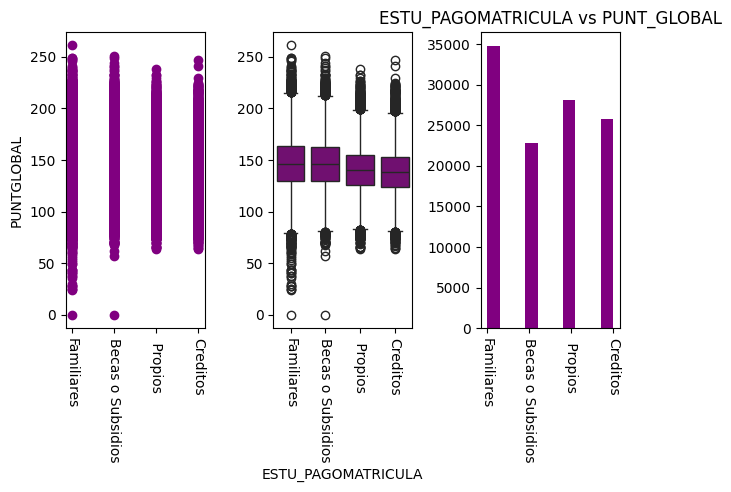

<Figure size 300x100 with 0 Axes>

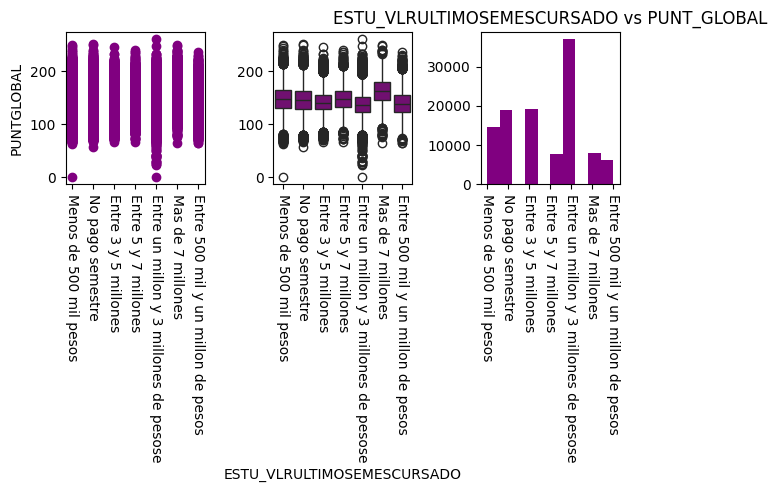

<Figure size 300x100 with 0 Axes>

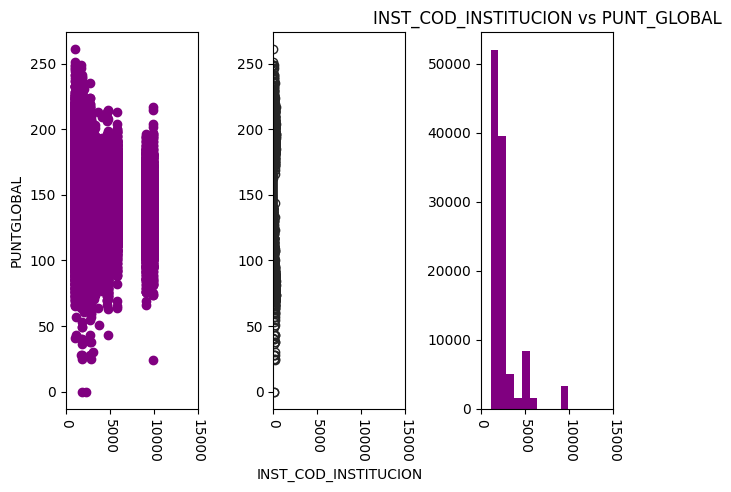

<Figure size 300x100 with 0 Axes>

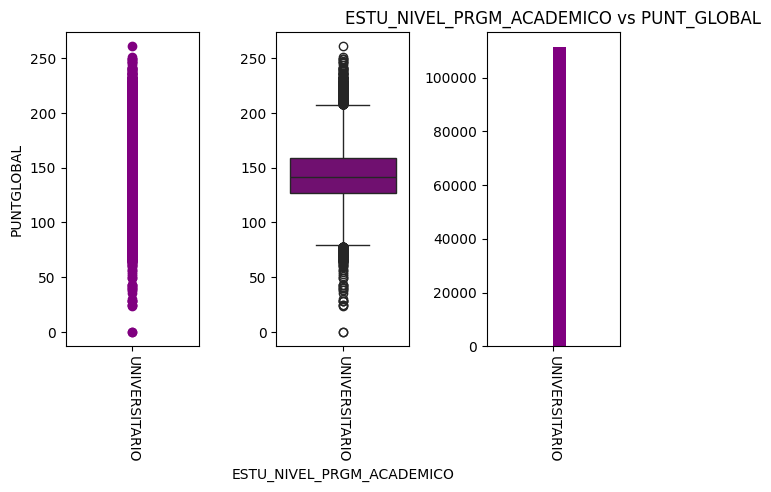

<Figure size 300x100 with 0 Axes>

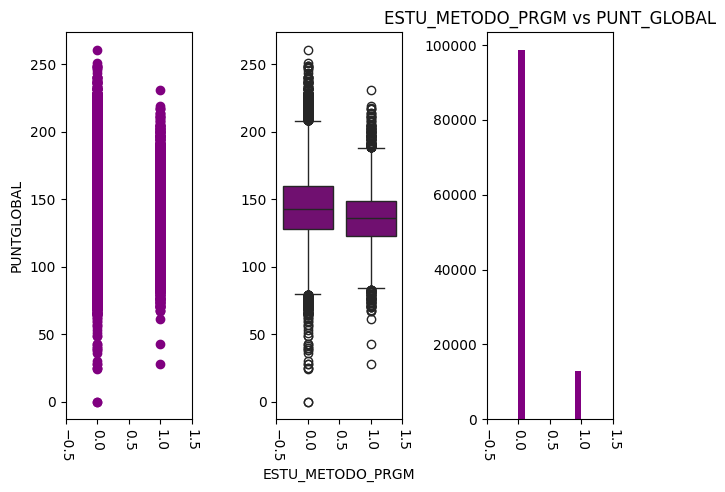

<Figure size 300x100 with 0 Axes>

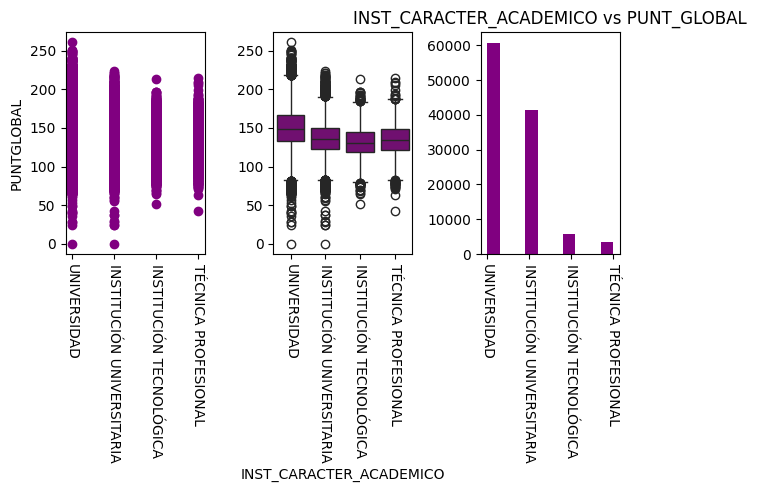

<Figure size 300x100 with 0 Axes>

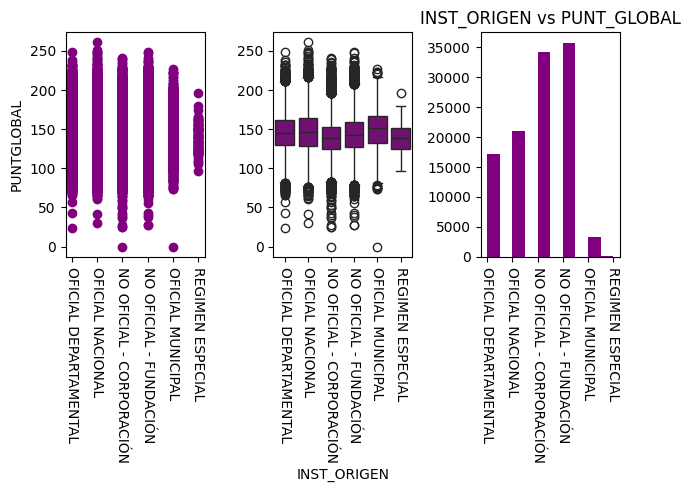

<Figure size 300x100 with 0 Axes>

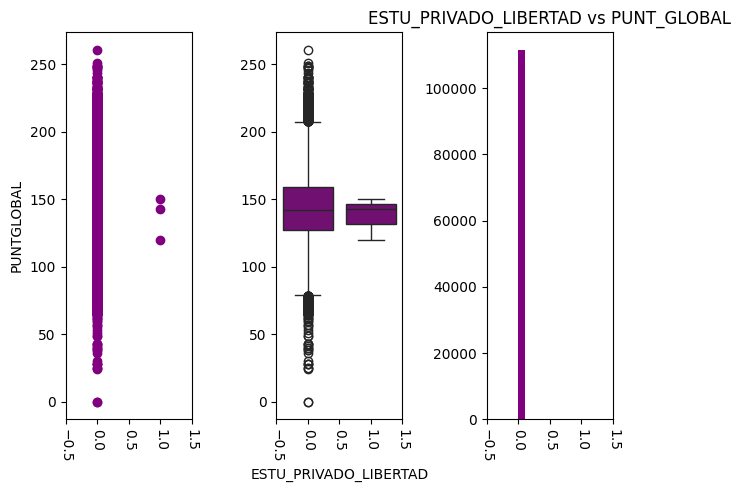

In [8]:
for col in categorical_cols:

    d = plt.figure(figsize=(3,1))
    d, ax = plt.subplots(ncols=3)

    ax[0].scatter(est_train[col],est_train["PUNT_GLOBAL"], c="purple")
    ax[0].set_xticks(ax[0].get_xticks())
    ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=-90)
    ax[0].set_ylabel("PUNTGLOBAL")

    if (col != "ESTU_FECHANACIMIENTO"):
        sns.boxplot(x=est_train[col], y=est_train["PUNT_GLOBAL"], ax=ax[1], color="purple")
        ax[1].set_xlabel(col)
        ax[1].set_ylabel("")
        ax[1].set_xticks(ax[0].get_xticks())
        ax[1].set_xticklabels(ax[0].get_xticklabels(), rotation=-90)

    ax[2].hist(est_train[col], color="purple")
    ax[2].set_xticks(ax[0].get_xticks())
    ax[2].set_xticklabels(ax[0].get_xticklabels(), rotation=-90)

    d.tight_layout()

    plt.title(f"{col} vs PUNT_GLOBAL")
    plt.show()

### 2. Divida los datos en training y testing

In [13]:
x, y = est_train_dumm[[col for col in est_train_dumm.columns if col != "PUNT_GLOBAL"]], est_train["PUNT_GLOBAL"]
xr, xs, yr, ys = train_test_split(x, y, test_size=0.2, random_state=42)

#### 2.1 Aplique las transformaciones más importantes a los datos. (Hint calcular la edad basada en la fecha de nacimiento, agrupar variables categóricas con mucha cardinalidad en grupos).
[Ver 1.3](#13-crear-dummy-variables-para-incluirlas-en-la-correlación)

#### 2.2 Entrenar un modelos de regresión

In [14]:
reg = LinearRegression()
reg.fit(xr, yr)

LinearRegression()

#### 2.3 ¿Cuál es el mejor R squared? Cuál es el MAPE y el MSE.

In [15]:
yr_hat = reg.predict(xr)

def get_r2(true, pred):
    SSR, SST = sum((true-pred)**2), sum((true-np.mean(true))**2)
    R2 = 1 - (float(SSR))/SST
    return R2

def get_mse(true, pred):
    return (1/len(true))*sum((true-pred)**2)

def get_mape(true, pred):
    return (100/len(true)*sum(abs(pred-true)/true))

print("Training:")
print("R²   ", get_r2(yr, yr_hat))
print("MAPE ", get_mape(yr, yr_hat), "(Hay puntajes en 0)")
print("MSE  ", get_mse(yr, yr_hat))

Training:
R²    0.2692163693506392
MAPE  inf (Hay puntajes en 0)
MSE   401.4233296173137


### 3. Remueva las variables que nos son relevantes

[Ver 1.1](#11-qué-variables-son-importantes-para-predecir-el-valor)

### 4. Utilizando los datos de test medir el MAPE y el MSE de test. Qué tan diferentes son las métricas de training. (El menor error del grupo tiene un +1)

In [16]:
ys_hat = reg.predict(xs)

print("Test:")
print("R²   ", get_r2(ys, ys_hat))
print("MAPE ", get_mape(ys, ys_hat), "(Hay puntajes en 0)")
print("MSE  ", get_mse(ys, ys_hat))

Test:
R²    0.274975769118024
MAPE  inf (Hay puntajes en 0)
MSE   401.51609480225244


No hay mucha diferencia respecto al training.

### 5. Describa en palabras que dice el modelo cuales son los principales hallazgos.

El principal hallazgo es que el las variables seleccionadas no son buenas para explicar la variabilidad del puntaje global, ya que se obtuvo un valor un poco bajo. 

In [17]:
est_test_raw = pd.read_csv("data/test_pruebas.csv", low_memory=False)
est_test = est_test_raw.drop(columns=irrelevant_cols)
est_test = fix_nulls(est_test)
transform_data(est_test)
est_test_dumm = pd.get_dummies(est_test)
normalize(est_test_dumm)
est_test_dumm

,ESTU_GENERO,ESTU_FECHANACIMIENTO,ESTU_EXTERIOR,ESTU_AREARESIDE,ESTU_PAGOMATRICULABECA,ESTU_PAGOMATRICULACREDITO,ESTU_PAGOMATRICULAPADRES,ESTU_PAGOMATRICULAPROPIO,ESTU_SIMULACROTIPOICFES,ESTU_ACTIVIDADREFUERZOAREAS,...,INST_CARACTER_ACADEMICO_INSTITUCIÓN TECNOLÓGICA,INST_CARACTER_ACADEMICO_INSTITUCIÓN UNIVERSITARIA,INST_CARACTER_ACADEMICO_TÉCNICA PROFESIONAL,INST_CARACTER_ACADEMICO_UNIVERSIDAD,INST_ORIGEN_NO OFICIAL - CORPORACIÓN,INST_ORIGEN_NO OFICIAL - FUNDACIÓN,INST_ORIGEN_OFICIAL DEPARTAMENTAL,INST_ORIGEN_OFICIAL MUNICIPAL,INST_ORIGEN_OFICIAL NACIONAL,INST_ORIGEN_REGIMEN ESPECIAL
0,0.873960,3.005238,-0.122216,0.362459,-0.653165,1.643914,-0.833058,-0.946695,0.075763,0.09706,...,-0.238635,-0.760661,-0.17643,0.905627,-0.660780,-0.682727,-0.432676,-0.173926,2.064469,-0.032281
1,-1.144175,-0.424237,-0.122216,0.362459,1.530951,-0.608282,-0.833058,-0.946695,0.075763,0.09706,...,-0.238635,-0.760661,-0.17643,0.905627,-0.660780,-0.682727,-0.432676,-0.173926,2.064469,-0.032281
2,0.873960,-0.281342,-0.122216,0.362459,-0.653165,-0.608282,-0.833058,-0.946695,0.075763,0.09706,...,-0.238635,-0.760661,-0.17643,0.905627,-0.660780,-0.682727,2.311117,-0.173926,-0.484369,-0.032281
3,0.873960,0.290237,-0.122216,0.362459,-0.653165,-0.608282,1.200354,-0.946695,0.075763,0.09706,...,-0.238635,1.314600,-0.17643,-1.104168,1.513309,-0.682727,-0.432676,-0.173926,-0.484369,-0.032281
4,0.873960,0.290237,8.181928,0.362459,-0.653165,-0.608282,-0.833058,-0.946695,0.075763,0.09706,...,-0.238635,1.314600,-0.17643,-1.104168,-0.660780,1.464661,-0.432676,-0.173926,-0.484369,-0.032281
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27853,0.873960,0.576026,-0.122216,0.362459,-0.653165,1.643914,-0.833058,1.056269,0.075763,0.09706,...,-0.238635,1.314600,-0.17643,-1.104168,-0.660780,1.464661,-0.432676,-0.173926,-0.484369,-0.032281
27854,-1.144175,-0.710027,-0.122216,0.362459,-0.653165,1.643914,1.200354,-0.946695,0.075763,0.09706,...,-0.238635,-0.760661,-0.17643,0.905627,-0.660780,1.464661,-0.432676,-0.173926,-0.484369,-0.032281
27855,0.873960,3.433922,-0.122216,0.362459,1.530951,-0.608282,-0.833058,-0.946695,0.075763,0.09706,...,-0.238635,-0.760661,-0.17643,0.905627,-0.660780,-0.682727,2.311117,-0.173926,-0.484369,-0.032281
27856,0.873960,-0.138447,-0.122216,0.362459,-0.653165,-0.608282,1.200354,1.056269,0.075763,0.09706,...,-0.238635,-0.760661,-0.17643,0.905627,-0.660780,1.464661,-0.432676,-0.173926,-0.484369,-0.032281


In [19]:
est_test_pred = reg.predict(est_test_dumm)
output = pd.DataFrame(est_test_pred, columns=["GLOBAL_SCORE"])

with open("output/Regression.csv", mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["id","GLOBAL_SCORE"])
    for i, val in enumerate(np.array(output["GLOBAL_SCORE"])):
        writer.writerow([est_test_raw["ESTU_CONSECUTIVO"][i],val])

output

,GLOBAL_SCORE
0,131.813618
1,160.129069
2,150.706679
3,128.874464
4,157.649999
...,...
27853,136.930773
27854,156.567431
27855,131.724934
27856,150.551950


## Crear un modelo de KNN

Utilizar los datos para crear un modelo de KNN que permita predecir el puntaje por estudiante.

In [20]:
x, y = est_train_dumm[[col for col in est_train_dumm.columns if col != "PUNT_GLOBAL"]], est_train["PUNT_GLOBAL"]
xr, xs, yr, ys = train_test_split(x, y, test_size=0.2, random_state=42)

### 2.1 Hacer pruebas con 5, 10, 20 y 30 vecinos. Seleccione el numero de vecinos basado en el error de test MSE.

In [21]:
neightbor_sizes = [5,10,20,30]

for s in neightbor_sizes:
    knn = KNeighborsRegressor(n_neighbors=s)
    knn.fit(xr, yr)
    yr_hat = knn.predict(xr)
    print(f"{s} vecinos:")
    print("MSE(train)   ", get_mse(yr, yr_hat))
    print("MAPE(train)  ", get_mape(yr, yr_hat))

    ys_hat = knn.predict(xs)
    print("MSE(test)    ", get_mse(ys, ys_hat))
    print("MAPE(test)   ", get_mape(ys, ys_hat))

    print("---------------------------------")

5 vecinos:
MSE(train)    318.5757408238356
MAPE(train)   inf
MSE(test)     480.4681522031769
MAPE(test)    inf
---------------------------------
10 vecinos:
MSE(train)    359.4831544467379
MAPE(train)   inf
MSE(test)     442.9556892219331
MAPE(test)    inf
---------------------------------
20 vecinos:
MSE(train)    383.0111103663735
MAPE(train)   inf
MSE(test)     426.01821592030876
MAPE(test)    inf
---------------------------------
30 vecinos:
MSE(train)    391.51327341779097
MAPE(train)   inf
MSE(test)     420.2776414191272
MAPE(test)    inf
---------------------------------


El MSE de test mejora con cada vez más vecinos, así que voy a probar con 100.

In [22]:
knn = KNeighborsRegressor(n_neighbors=100)
knn.fit(xr, yr)
ys_hat = knn.predict(xs)
print("100 vecinos:")
print("MSE(test)    ", get_mse(ys, ys_hat))
print("MAPE(test)   ", get_mape(ys, ys_hat))

est_test_pred = knn.predict(est_test_dumm)
output = pd.DataFrame(est_test_pred, columns=["GLOBAL_SCORE"])

with open("output/KNN.csv", mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["id","GLOBAL_SCORE"])
    for i, val in enumerate(np.array(output["GLOBAL_SCORE"])):
        writer.writerow([est_test_raw["ESTU_CONSECUTIVO"][i],val])

output

100 vecinos:
MSE(test)     418.96429585838644
MAPE(test)    inf


,GLOBAL_SCORE
0,132.43
1,146.81
2,150.82
3,131.98
4,147.68
...,...
27853,134.98
27854,143.40
27855,138.64
27856,138.93


### 2.2 Describa cual es mejor modelo entre la regresión o el knn.

En general, la regresión lineal resulta ser más efectiva

## 3. Crear un modelo de GBM

Entrenar un modelo de GBM y hacer la predicción. Cual es el MSE y MAPE para train y test.

In [23]:
x, y = est_train_dumm[[col for col in est_train_dumm.columns if col != "PUNT_GLOBAL"]], est_train["PUNT_GLOBAL"]
xr, xs, yr, ys = train_test_split(x, y, test_size=0.2, random_state=42)

gbm = LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42, verbose=0)
gbm.fit(xr, yr)

yr_hat = gbm.predict(xr)

print("Train: ")
print("MSE(train)    ", get_mse(yr, yr_hat))
print("MAPE(train)   ", get_mape(yr, yr_hat))

ys_hat = gbm.predict(xs)

print("Test: ")
print("MSE(test)    ", get_mse(ys, ys_hat))
print("MAPE(test)   ", get_mape(ys, ys_hat))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning]

In [24]:
est_test_pred = gbm.predict(est_test_dumm)
output = pd.DataFrame(est_test_pred, columns=["GLOBAL_SCORE"])

with open("output/GBM.csv", mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(["id","GLOBAL_SCORE"])
    for i, val in enumerate(np.array(output["GLOBAL_SCORE"])):
        writer.writerow([est_test_raw["ESTU_CONSECUTIVO"][i],val])

output

,GLOBAL_SCORE
0,153
1,153
2,153
3,153
4,153
...,...
27853,153
27854,153
27855,153
27856,153


## 4. Crear un modelo de regresión logística

Utiliza los mismos datos del punto 1, crea una variable Y donde las personas con puntajemayor a 172 tienen “1” y los demás “0” (‘1’ if PUNT_GLOBAL>172 else ‘0’), la variable Y representa los estudiantes sobresalientes, eliminar la variable PUNT_GLOBAL.

In [25]:
x, y = est_train_dumm[[col for col in est_train_dumm.columns if col != "PUNT_GLOBAL"]], (est_train["PUNT_GLOBAL"] > 172).astype(int)

Con el dataset de training:
- Dividir los datos en training 80% y validación 20%.
- Entrenar una regresión logística, cuales son las variables más importantes?.
- Crear una matriz de confusión, cual es la precisión, cuál es el recall, y el accuracy.
- Calcular las mismas métricas para el dataset de validación.

In [26]:
xr, xs, yr, ys = train_test_split(x, y, test_size=0.2, random_state=42)

lgr = LogisticRegression()
lgr.fit(xr, yr)

yr_hat = lgr.predict(xr)

print("Regresión logítisca")
print("MSE(train):", get_mse(yr_hat, yr))

ys_hat = lgr.predict(xs)

print("MSE(test):", get_mse(ys_hat, ys))

Regresión logítisca
MSE(train): 0.10811720362559454
MSE(test): 0.11141523826617608


La importancia la determinaré con los coeficientes, están organizadas por el valor del coeficiente.

In [27]:
importance = pd.DataFrame({'Variable': est_test_dumm.columns, 'Coeficiente': lgr.coef_[0]}).sort_values(ascending=False, by=["Coeficiente"]).iloc[1:]
importance

,Variable,Coeficiente
111,INST_CARACTER_ACADEMICO_UNIVERSIDAD,0.201224
3,ESTU_AREARESIDE,0.186003
14,FAMI_TIENEHORNOMICROOGAS,0.175395
22,ESTU_INSE_INDIVIDUAL,0.172372
116,INST_ORIGEN_OFICIAL NACIONAL,0.163433
...,...,...
17,FAMI_TIENEMOTOCICLETA,-0.194038
0,ESTU_GENERO,-0.195658
84,FAMI_ESTRATOVIVIENDA_Estrato 1,-0.215724
112,INST_ORIGEN_NO OFICIAL - CORPORACIÓN,-0.225327


In [28]:
conf_r = pd.DataFrame(metrics.confusion_matrix(yr, yr_hat))
print("Filas: Real, Columnas: Predicción\n")
print("Matríz de confusión (Train)")
conf_r

Filas: Real, Columnas: Predicción

Matríz de confusión (Train)


,0,1
0,77467,1259
1,8379,2039


In [29]:
pre_r, acc_r, rec_r = precision_score(yr, yr_hat), accuracy_score(yr, yr_hat), recall_score(yr, yr_hat)
print("PRECISION:",pre_r)
print("ACCURACY:",acc_r)
print("RECALL:", rec_r)

PRECISION: 0.618253486961795
ACCURACY: 0.8918827963744055
RECALL: 0.19571894797465925


In [30]:
conf_s = pd.DataFrame(metrics.confusion_matrix(ys, ys_hat))
print("Matríz de confusión (Test)")
conf_s

Matríz de confusión (Test)


,0,1
0,19297,329
1,2154,506


In [ ]:
pre_s, acc_s, rec_s = precision_score(ys, ys_hat), accuracy_score(ys, ys_hat), recall_score(ys, ys_hat)
print("PRECISION:",pre_s)
print("ACCURACY:",acc_s)
print("RECALL:", rec_s)

PRECISION: 0.6059880239520958
ACCURACY: 0.888584761733824
RECALL: 0.19022556390977444
